In [1]:
import pandas as pd
import numpy as np
import networkx as nx

In [3]:
# df = pd.read_csv('/Users/mukesh/Documents/FLIPKART/data/Astram.csv')
d1 = pd.read_csv('/Users/mukesh/Documents/FLIPKART/backend/data/cluster_centers.csv')

In [9]:
import requests
import json

API_KEY = "UnPkjVwRHaoGYVDDtcDWZ1wGZ2hEVpR0"

url = "https://api.tomtom.com/search/2/reverseGeocode/12.9716,77.5946.json"

params = {
    "key": API_KEY
}

response = requests.get(url, params=params)

print(json.dumps(response.json(), indent=2))

{
  "summary": {
    "queryTime": 13,
    "numResults": 1
  },
  "addresses": [
    {
      "address": {
        "buildingNumber": "40/B",
        "streetNumber": "40/B",
        "routeNumbers": [],
        "street": "Vittal Mallya Road",
        "streetName": "Vittal Mallya Road",
        "streetNameAndNumber": "40/B, Vittal Mallya Road",
        "countryCode": "IN",
        "countrySubdivision": "Karnataka",
        "countrySecondarySubdivision": "Bengaluru",
        "municipality": "Bengaluru",
        "postalCode": "560001",
        "municipalitySecondarySubdivision": "D Souza Layout",
        "country": "India",
        "countryCodeISO3": "IND",
        "freeformAddress": "40/B, Vittal Mallya Road, D Souza Layout, Bengaluru 560001, Karnataka",
        "boundingBox": {
          "northEast": "12.971783,77.594620",
          "southWest": "12.970836,77.594179",
          "entity": "position"
        },
        "countrySubdivisionName": "Karnataka",
        "countrySubdivisionCode": "

In [10]:
import requests
import json

API_KEY = "UnPkjVwRHaoGYVDDtcDWZ1wGZ2hEVpR0"

url = "https://api.tomtom.com/traffic/services/5/incidentDetails"

params = {
    "bbox": "77.45,12.85,77.75,13.10",
    "fields": "{incidents{type,geometry{type,coordinates},properties{id,iconCategory,magnitudeOfDelay,events{description},startTime,endTime}}}",
    "key": API_KEY
}

response = requests.get(url, params=params)

print(response.status_code)
print(json.dumps(response.json(), indent=2))

200
{
  "incidents": [
    {
      "type": "Feature",
      "properties": {
        "id": "TTI-e367b474-7d1a-47e2-983e-df0f299b9145-TTL80552488808036000",
        "iconCategory": 6,
        "magnitudeOfDelay": 3,
        "startTime": "2026-06-18T14:33:30Z",
        "endTime": "2026-06-18T14:56:30Z",
        "events": [
          {
            "description": "Stationary traffic"
          }
        ]
      },
      "geometry": {
        "type": "LineString",
        "coordinates": [
          [
            77.4477794528,
            13.0844874881
          ],
          [
            77.4478934466,
            13.0843211816
          ],
          [
            77.4484660983,
            13.0836614243
          ],
          [
            77.4490561843,
            13.0829465559
          ],
          [
            77.4491125106,
            13.0828795267
          ],
          [
            77.4495926261,
            13.0823296578
          ],
          [
            77.4496985733,
      

In [ ]:
"""
dropping these cols as they are not useful for the current decision making
"""
drop_cols = [
    "map_file",
    "direction",
    "route_path",
    "comment",
    "meta_data",
    "veh_no",
    "created_by_id",
    "last_modified_by_id",
    "assigned_to_police_id",
    "citizen_accident_id",
    "closed_by_id",
    "resolved_by_id",
    "gba_identifier",
    "kgid"
]
df_clean.drop(columns=drop_cols, inplace=True, errors="ignore")

In [ ]:
# filling the missing with categorical values
cat_fill = {
    "address": "Unknown",
    "end_address": "Unknown",
    "description": "Unknown",
    "veh_type": "Unknown",
    "cargo_material": "None",
    "reason_breakdown": "Unknown",
    "corridor": "Unknown",
    "zone": "Unknown",
    "junction": "Unknown",
    "resolved_at_address": "Unknown"
}

for col, value in cat_fill.items():
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(value)

In [ ]:
# replacing the Nan with -1 as these are of numerical values
num_fill = {
    "endlatitude": df_clean["endlatitude"].median(),
    "endlongitude": df_clean["endlongitude"].median(),
    "priority": df_clean["priority"].mode()[0],
    "age_of_truck": -1,
    "resolved_at_latitude": df_clean["latitude"].median(),
    "resolved_at_longitude": df_clean["longitude"].median()
}

for col, value in num_fill.items():
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(value)

In [12]:
datetime_cols = [
    "start_datetime",
    "end_datetime",
    "modified_datetime",
    "created_date",
    "closed_datetime",
    "resolved_datetime"
]

for col in datetime_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

In [13]:
df_clean["hour"] = df_clean["start_datetime"].dt.hour
df_clean["day"] = df_clean["start_datetime"].dt.day
df_clean["month"] = df_clean["start_datetime"].dt.month
df_clean["day_of_week"] = df_clean["start_datetime"].dt.dayofweek
df_clean["weekend"] = (df_clean["day_of_week"] >= 5).astype(int)


In [14]:
if "end_datetime" in df_clean.columns:
    df_clean["duration_minutes"] = (
        df_clean["end_datetime"] -
        df_clean["start_datetime"]
    ).dt.total_seconds() / 60

    median_duration = df_clean["duration_minutes"].median()
    df_clean["duration_minutes"] = (
        df_clean["duration_minutes"]
        .fillna(median_duration)
    )

In [15]:
if "closed_datetime" in df_clean.columns:
    df_clean["is_closed"] = (
        df_clean["closed_datetime"]
        .notna()
        .astype(int)
    )

if "resolved_datetime" in df_clean.columns:
    df_clean["is_resolved"] = (
        df_clean["resolved_datetime"]
        .notna()
        .astype(int)
    )

In [16]:
# dropping the duplicates
df_clean.drop_duplicates(inplace=True)

#Resetting the index
df_clean.reset_index(drop=True, inplace=True)

In [18]:
print("Shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isna().sum())
print(df_clean["event_type"].value_counts())
print(df_clean["event_cause"].value_counts())
print(df_clean["priority"].value_counts())

Shape: (8173, 40)

Missing values:
id                          0
event_type                  0
latitude                    0
longitude                   0
endlatitude                 0
endlongitude                0
address                     0
end_address                 0
event_cause                 0
requires_road_closure       0
start_datetime            116
end_datetime             7698
status                      0
authenticated               0
modified_datetime           0
description                 0
veh_type                    0
corridor                    0
priority                    0
cargo_material              0
reason_breakdown            0
age_of_truck                0
created_date                2
client_id                   0
police_station              0
resolved_at_address         0
resolved_at_latitude        0
resolved_at_longitude       0
closed_datetime          5032
resolved_datetime        8099
zone                        0
junction                    0
hour 

In [19]:
df_clean.to_csv(
    "cleaned_event_dataset.csv", index=False
)

In [20]:
planned_df = df_clean[
    df_clean["event_type"] == "planned"
]

planned_df.to_csv(
    "planned_events.csv",
    index=False
)

unplanned_df = df_clean[
    df_clean["event_type"] == "unplanned"
]

unplanned_df.to_csv(
    "unplanned_event.csv", index=False
)

In [21]:
ml_df = df_clean.copy()

ml_df.to_csv(
    "traffic_events_ml.csv",
    index=False
)

Matplotlib is building the font cache; this may take a moment.


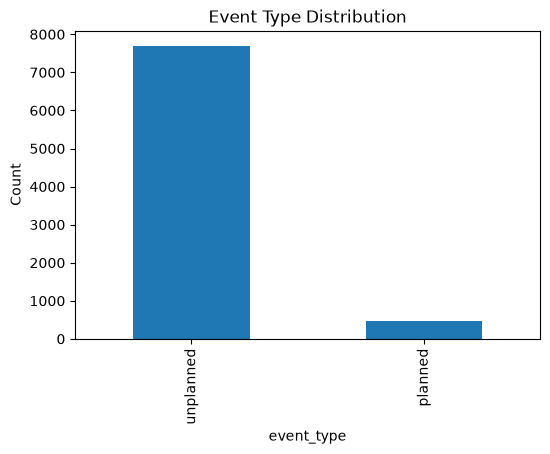

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df_clean["event_type"].value_counts().plot(kind="bar")
plt.title("Event Type Distribution")
plt.ylabel("Count")
plt.show()

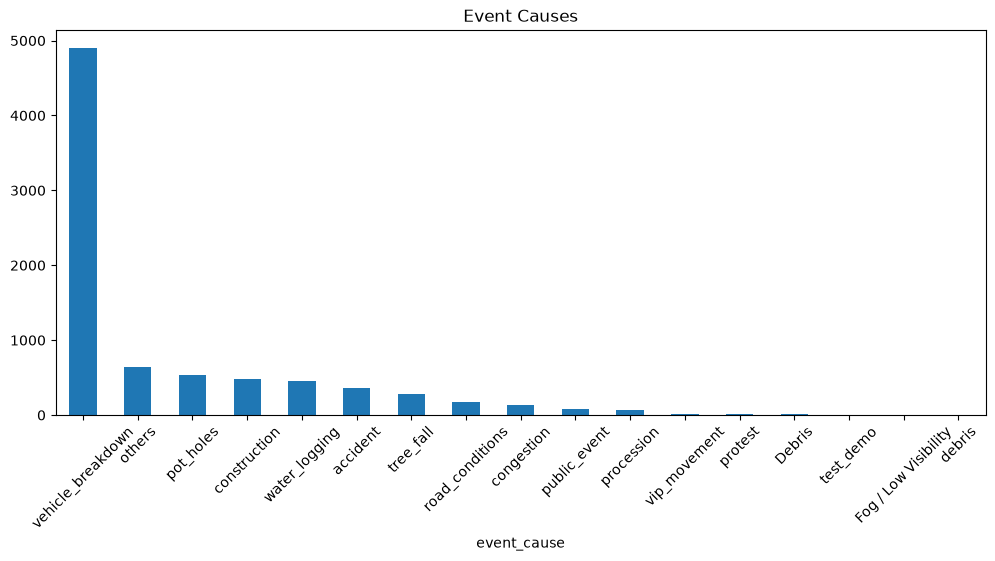

In [23]:
plt.figure(figsize=(12,5))

df_clean["event_cause"].value_counts().plot(
    kind="bar"
)

plt.xticks(rotation=45)
plt.title("Event Causes")
plt.show()

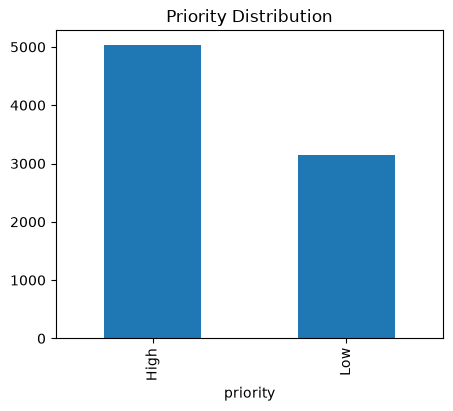

In [24]:
plt.figure(figsize=(5,4))

df_clean["priority"].value_counts().plot(
    kind="bar"
)

plt.title("Priority Distribution")
plt.show()

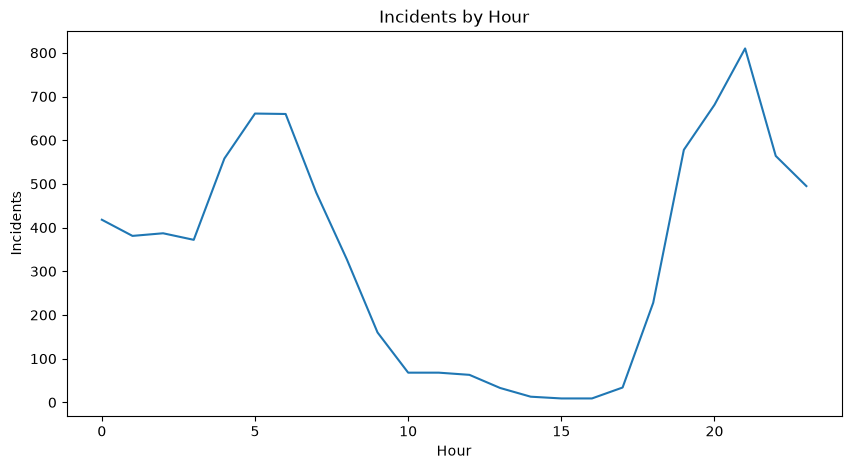

In [25]:
plt.figure(figsize=(10,5))

df_clean["hour"].value_counts().sort_index().plot()

plt.xlabel("Hour")
plt.ylabel("Incidents")
plt.title("Incidents by Hour")
plt.show()

In [26]:
import folium
from folium.plugins import HeatMap

m = folium.Map(
    location=[12.97,77.59],
    zoom_start=11
)

heat_data = df_clean[
    ["latitude","longitude"]
].values.tolist()

HeatMap(heat_data).add_to(m)

m.save("incident_heatmap.html")